In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder

### Cargar datos

In [25]:
ruta_energia = "energiasedif1(11 pisosycomunes).csv"
ruta_agua = "VOLUMENAGUACALIENTECONSUMIDA.csv"

df_energia = pd.read_csv(ruta_energia)
df_agua = pd.read_csv(ruta_agua)

In [26]:
df_agua.tail()

,Unnamed: 0,volumenBA,volumenBB,volumen1C,volumen2A,volumen2B,volumen3A,volumen3B,volumen4A,volumen4B,volumen5A,volumen5B
9523,2026-02-01 19:00:00,2836.0,9151.00,10757.0,7790.23,8008.0,3448.0,3051.0,329.0,3054.0,4522.0,5568.0
9524,2026-02-01 20:00:00,2836.0,9151.00,10757.0,7791.00,8008.0,3448.0,3051.0,329.0,3054.0,4522.0,5568.0
9525,2026-02-01 21:00:00,2836.0,9151.00,10757.0,7792.22,8008.0,3448.0,3051.0,329.0,3054.0,4522.0,5568.0
9526,2026-02-01 22:00:00,2836.0,9153.95,10757.0,7793.48,8008.0,3448.0,3051.0,329.0,3054.0,4522.0,5568.0
9527,2026-02-01 23:00:00,2836.0,9154.00,10757.0,7794.00,8008.0,3448.0,3051.0,329.0,3054.0,4522.0,5568.0


In [27]:
# renombrar la primera columna como 'fecha'
df_energia = df_energia.rename(columns={df_energia.columns[0]: "fecha"})
df_agua = df_agua.rename(columns={df_agua.columns[0]: "fecha"})

# convertir fecha
df_energia["fecha"] = pd.to_datetime(df_energia["fecha"], errors="coerce")
df_agua["fecha"] = pd.to_datetime(df_agua["fecha"], errors="coerce")

# eliminar filas iniciales vacías
cols_energia_sin_fecha = df_energia.columns[1:]
cols_agua_sin_fecha = df_agua.columns[1:]

mask_energia = df_energia[cols_energia_sin_fecha].notna().any(axis=1)
mask_agua = df_agua[cols_agua_sin_fecha].notna().any(axis=1)

primera_fila_energia = mask_energia.idxmax()
primera_fila_agua = mask_agua.idxmax()

df_energia = df_energia.loc[primera_fila_energia:].reset_index(drop=True)
df_agua = df_agua.loc[primera_fila_agua:].reset_index(drop=True)

In [28]:
cols_pisos_energia = [c for c in df_energia.columns if c.startswith("energia") and c != "energia"]
cols_pisos_agua = [c for c in df_agua.columns if c.startswith("volumen")]

print("Columnas energía por piso:")
print(cols_pisos_energia)

print("\nColumnas agua por piso:")
print(cols_pisos_agua)

Columnas energía por piso:
['energiaBA', 'energiaBB', 'energia1C', 'energia2A', 'energia2B', 'energia3A', 'energia3B', 'energia4A', 'energia4B', 'energia5A', 'energia5B']

Columnas agua por piso:
['volumenBA', 'volumenBB', 'volumen1C', 'volumen2A', 'volumen2B', 'volumen3A', 'volumen3B', 'volumen4A', 'volumen4B', 'volumen5A', 'volumen5B']


### Crear columnas no acumulativas

In [30]:
# como son variables acumulativas, restar para encontrar aumento 
for col in cols_pisos_energia + ["energia"]:
    df_energia[col] = pd.to_numeric(df_energia[col], errors="coerce")

for col in cols_pisos_agua:
    df_agua[col] = pd.to_numeric(df_agua[col], errors="coerce")

df_energia_diff = df_energia.copy()
df_agua_diff = df_agua.copy()

for col in cols_pisos_energia + ["energia"]:
    df_energia_diff[col] = df_energia_diff[col].diff()

for col in cols_pisos_agua:
    df_agua_diff[col] = df_agua_diff[col].diff()

In [41]:
(df_energia_diff["energia3A"] == 0).sum()

7839

In [42]:
df_energia_diff["energia3A"].count()

8148

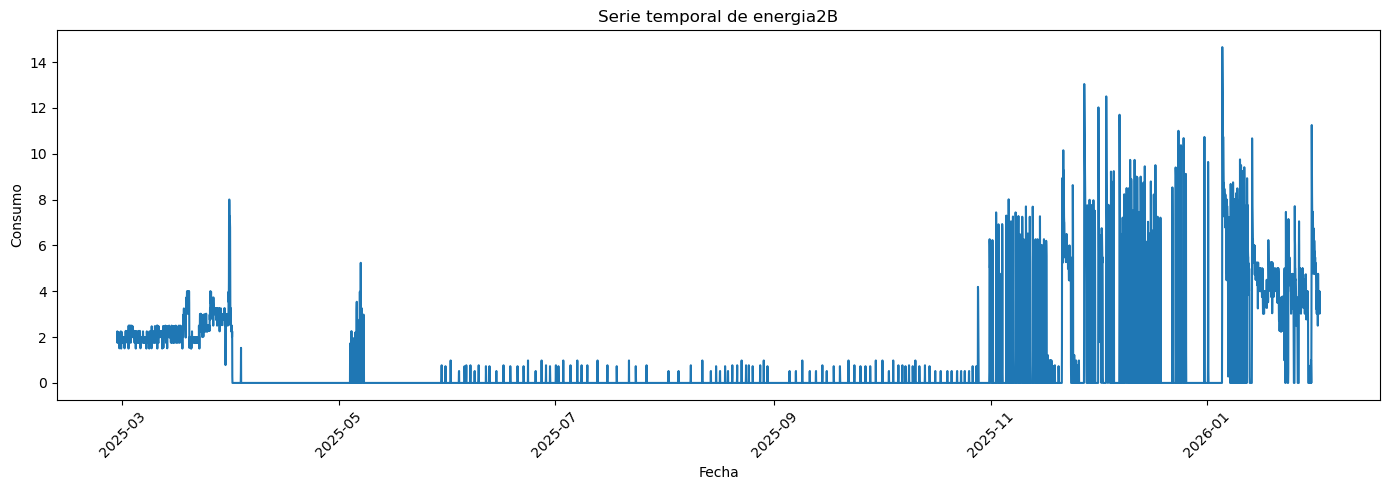

In [49]:
plt.figure(figsize=(14,5))
plt.plot(df_energia_diff["fecha"], df_energia_diff["energiaBB"])
plt.title("Serie temporal de energia2B")
plt.xlabel("Fecha")
plt.ylabel("Consumo")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

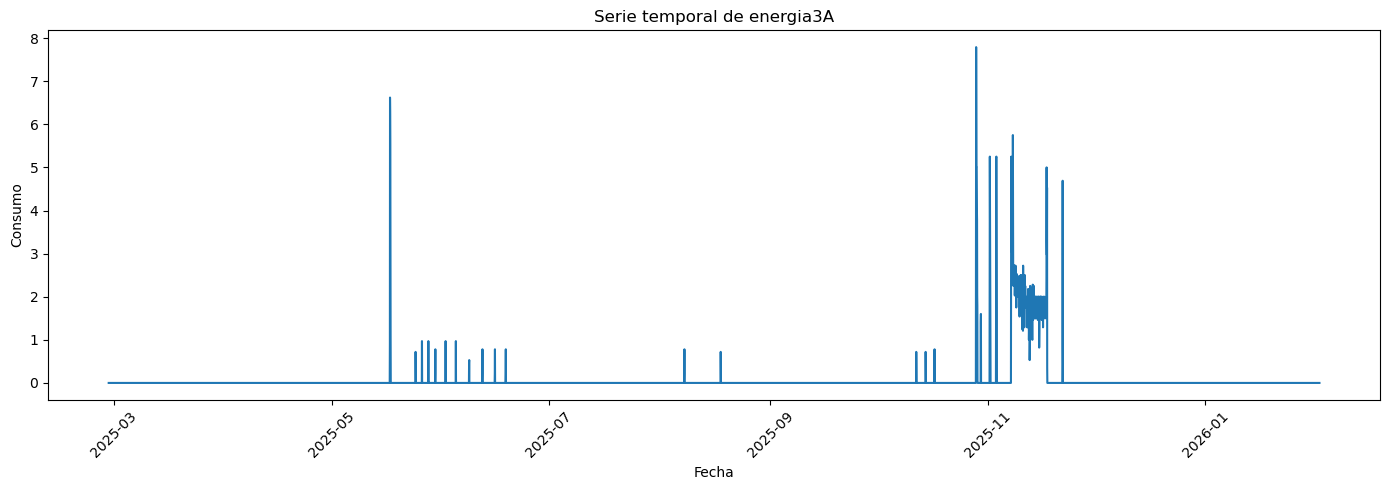

In [45]:
plt.figure(figsize=(14,5))
plt.plot(df_energia_diff["fecha"], df_energia_diff["energia3A"])
plt.title("Serie temporal de energia3A")
plt.xlabel("Fecha")
plt.ylabel("Consumo")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [40]:
(df_energia_diff["energia2B"] == df_energia_diff["energia2B"].shift(1)).sum()

6800

In [32]:
df_agua.head()

,fecha,volumenBA,volumenBB,volumen1C,volumen2A,volumen2B,volumen3A,volumen3B,volumen4A,volumen4B,volumen5A,volumen5B
0,2025-02-27 11:00:00,2210.53,4853.0,9399.0,4924.00,7462.0,1870.0,2527.0,262.0,2276.0,2249.0,3591.00
1,2025-02-27 12:00:00,2216.23,4853.0,9399.0,4924.00,7462.0,1870.0,2527.0,262.0,2276.0,2249.0,3591.00
2,2025-02-27 13:00:00,2217.73,4853.0,9399.0,4924.00,7462.0,1870.0,2527.0,262.0,2276.0,2249.0,3591.00
3,2025-02-27 14:00:00,2218.00,4853.0,9399.0,4925.72,7462.0,1870.0,2527.0,262.0,2276.0,2249.0,3591.00
4,2025-02-27 15:00:00,2218.00,4853.0,9399.0,4926.00,7462.0,1870.0,2527.0,262.0,2276.0,2249.0,3592.35


In [33]:
df_agua_diff.head()

,fecha,volumenBA,volumenBB,volumen1C,volumen2A,volumen2B,volumen3A,volumen3B,volumen4A,volumen4B,volumen5A,volumen5B
0,2025-02-27 11:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-02-27 12:00:00,5.70,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00
2,2025-02-27 13:00:00,1.50,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00
3,2025-02-27 14:00:00,0.27,0.0,0.0,1.72,0.0,0.0,0.0,0.0,0.0,0.0,0.00
4,2025-02-27 15:00:00,0.00,0.0,0.0,0.28,0.0,0.0,0.0,0.0,0.0,0.0,1.35


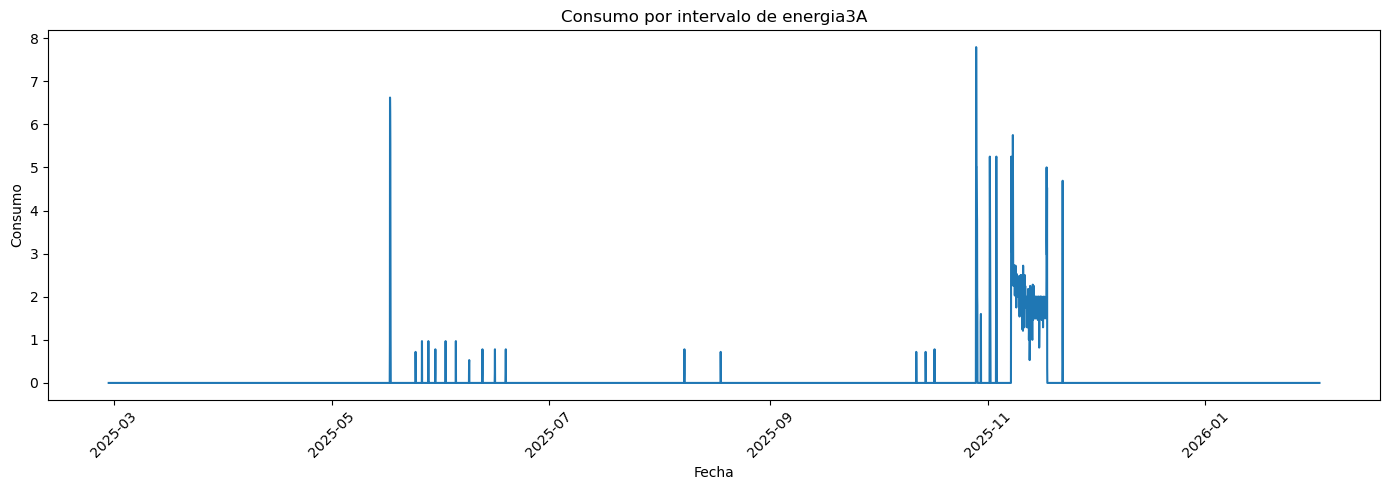

In [47]:
col_ejemplo = cols_pisos_energia[5]

plt.figure(figsize=(14,5))
plt.plot(df_energia_diff["fecha"], df_energia_diff[col_ejemplo])
plt.title(f"Consumo por intervalo de {col_ejemplo}")
plt.xlabel("Fecha")
plt.ylabel("Consumo")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [35]:

import plotly.express as px

fig = px.line(
    df_energia_diff,
    x="fecha",
    y="energia3a",
    title="Consumo por intervalo"
)

fig.update_traces(
    mode="lines+markers",
    hovertemplate="Fecha: %{x}<br>Consumo: %{y}<extra></extra>"
)

fig.update_layout(
    xaxis_title="Fecha",
    yaxis_title="Consumo"
)

fig.show()

ValueError: Value of 'y' is not the name of a column in 'data_frame'. Expected one of ['fecha', 'POTENCIA ACTIVA', 'energia', 'etermicaconserje', 'CAUDAL AGUA CALIENTE', 'erefrigeración conserje', 'etermicasolar', 'energiaBA', 'energiaBB', 'energia1C', 'energia2A', 'energia2B', 'energia3A', 'energia3B', 'energia4A', 'energia4B', 'energia5A', 'energia5B'] but received: energia3a

In [ ]:
def plot_month_apartment(
    df_energia_diff,
    df_agua_diff,
    data_type="energia", #'energia' or 'agua'
    apartment="energia3A",
    year=2025,
    month=11,
    daily=False,
    kind="line"
):
    """
    Plot energy or water consumption for one apartment in a chosen month and year.

    Parameters
    ----------
    df_energia_diff : pandas.DataFrame
        DataFrame with non-cumulative energy data. Must contain a 'fecha' column.
    df_agua_diff : pandas.DataFrame
        DataFrame with non-cumulative water data. Must contain a 'fecha' column.
    data_type : str
        'energia' or 'agua'
    apartment : str
        Example: 'energia1C' or 'volumen1C'
    year : int
        Year to plot
    month : int
        Month to plot (1 to 12)
    daily : bool
        If True, aggregates by day inside the selected month
    kind : str
        'line' or 'bar'
    """

    # Validate inputs
    if data_type not in ["energia", "agua"]:
        raise ValueError("data_type must be 'energia' or 'agua'")

    if not 1 <= month <= 12:
        raise ValueError("month must be between 1 and 12")

    if kind not in ["line", "bar"]:
        raise ValueError("kind must be 'line' or 'bar'")

    # Select dataframe
    if data_type == "energia":
        df = df_energia_diff.copy()
        ylabel = "Energy consumption"
    else:
        df = df_agua_diff.copy()
        ylabel = "Water consumption"

    # Check fecha column
    if "fecha" not in df.columns:
        raise ValueError("The selected dataframe must contain a 'fecha' column")

    # Convert fecha to datetime
    df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")

    # Check apartment column
    if apartment not in df.columns:
        raise ValueError(f"'{apartment}' is not a column in the selected dataframe")

    # Keep only selected month and year
    df_plot = df[
        (df["fecha"].dt.year == year) &
        (df["fecha"].dt.month == month)
    ].copy()

    if df_plot.empty:
        print(f"No data found for {apartment} in {year}-{month:02d}")
        return

    # Keep only the columns we need
    df_plot = df_plot[["fecha", apartment]].dropna()

    if df_plot.empty:
        print(f"No non-null data found for {apartment} in {year}-{month:02d}")
        return

    # Aggregate daily if requested
    if daily:
        df_plot = df_plot.set_index("fecha").resample("D").sum().reset_index()
        title_period = f"{year}-{month:02d} (daily)"
    else:
        title_period = f"{year}-{month:02d}"

    # Plot
    plt.figure(figsize=(14, 5))

    if kind == "line":
        plt.plot(df_plot["fecha"], df_plot[apartment], marker="o")
    elif kind == "bar":
        plt.bar(df_plot["fecha"].astype(str), df_plot[apartment])

    plt.title(f"{data_type.capitalize()} consumption - {apartment} - {title_period}")
    plt.xlabel("Date")
    plt.ylabel(ylabel)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

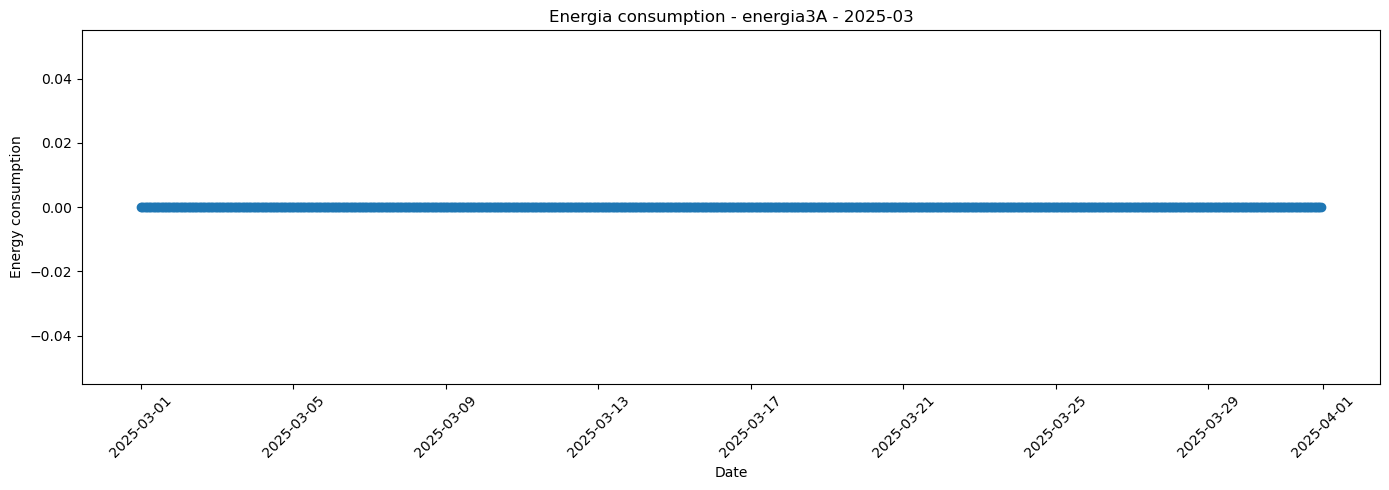

In [ ]:
plot_month_apartment(df_energia_diff, df_agua_diff,month=3)

### Crear modelo XGB

Shape final del dataset de entrenamiento: (87780, 14)
Train: (61457, 14)
Valid: (13167, 14)
Test: (13156, 14)
MAE: 0.4882698689208714
RMSE: 1.106669648634126


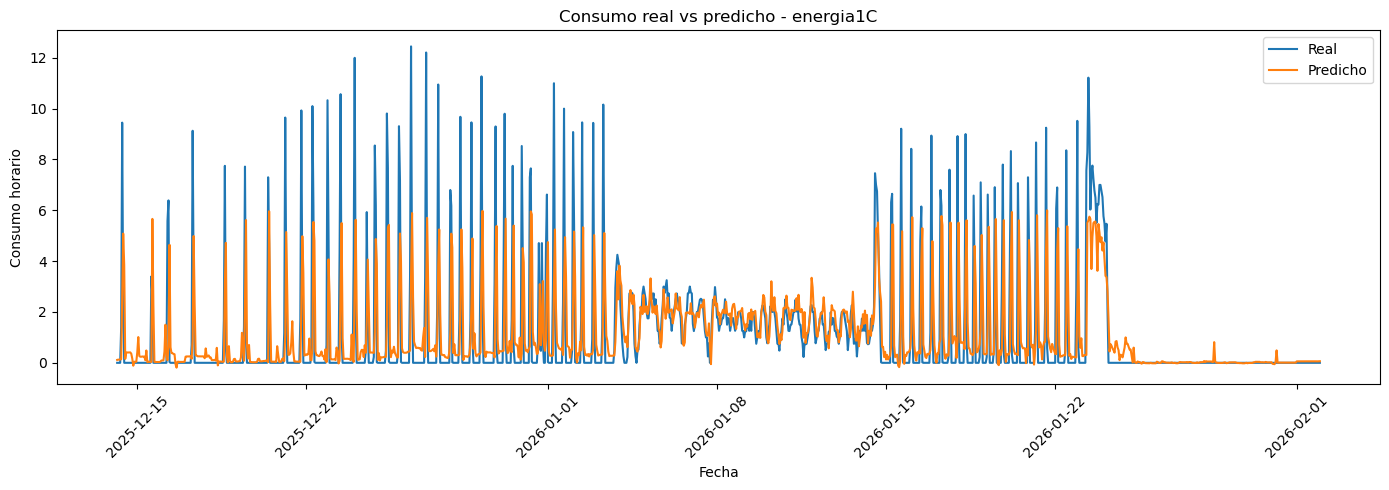

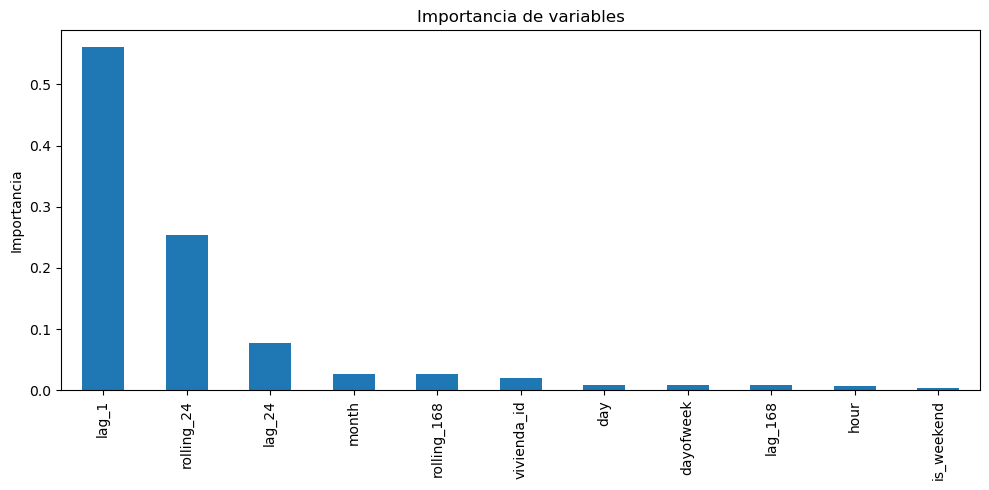

In [ ]:
# Nos quedamos solo con energía, no agua
df_train = df_energia_diff.copy()

# Si quieres, evita negativos raros tras diff
for col in cols_pisos_energia:
    df_train[col] = df_train[col].clip(lower=0)

# %%
# Pasar a formato largo: una fila = una hora de una vivienda
df_long = df_train.melt(
    id_vars="fecha",
    value_vars=cols_pisos_energia,
    var_name="vivienda",
    value_name="consumo"
)

df_long = df_long.dropna().copy()
df_long = df_long.sort_values(["vivienda", "fecha"]).reset_index(drop=True)

df_long.head()

# %%
# Variables temporales
df_long["hour"] = df_long["fecha"].dt.hour
df_long["dayofweek"] = df_long["fecha"].dt.dayofweek
df_long["day"] = df_long["fecha"].dt.day
df_long["month"] = df_long["fecha"].dt.month
df_long["is_weekend"] = (df_long["dayofweek"] >= 5).astype(int)

# %%
# Lags por vivienda
df_long["lag_1"] = df_long.groupby("vivienda")["consumo"].shift(1)
df_long["lag_24"] = df_long.groupby("vivienda")["consumo"].shift(24)
df_long["lag_168"] = df_long.groupby("vivienda")["consumo"].shift(168)

# %%
# Medias móviles por vivienda
df_long["rolling_24"] = (
    df_long.groupby("vivienda")["consumo"]
    .transform(lambda s: s.shift(1).rolling(24).mean())
)

df_long["rolling_168"] = (
    df_long.groupby("vivienda")["consumo"]
    .transform(lambda s: s.shift(1).rolling(168).mean())
)


# Codificar vivienda como número
le = LabelEncoder()
df_long["vivienda_id"] = le.fit_transform(df_long["vivienda"])

# Eliminar filas con nulos generados por lags/rolling
df_model = df_long.dropna().copy()

print("Shape final del dataset de entrenamiento:", df_model.shape)
df_model.head()

# División temporal: 70% train, 15% valid, 15% test
fechas_ordenadas = np.array(sorted(df_model["fecha"].unique()))
n = len(fechas_ordenadas)

train_end = fechas_ordenadas[int(n * 0.70)]
valid_end = fechas_ordenadas[int(n * 0.85)]

train = df_model[df_model["fecha"] <= train_end].copy()
valid = df_model[(df_model["fecha"] > train_end) & (df_model["fecha"] <= valid_end)].copy()
test = df_model[df_model["fecha"] > valid_end].copy()

print("Train:", train.shape)
print("Valid:", valid.shape)
print("Test:", test.shape)

features = [
    "vivienda_id",
    "hour",
    "dayofweek",
    "day",
    "month",
    "is_weekend",
    "lag_1",
    "lag_24",
    "lag_168",
    "rolling_24",
    "rolling_168"
]

target = "consumo"

X_train = train[features]
y_train = train[target]

X_valid = valid[features]
y_valid = valid[target]

X_test = test[features]
y_test = test[target]

# %%
model = XGBRegressor(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    verbose=False
)

# %%
# Predicción en test
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

# %%
# Guardar resultados
results = test[["fecha", "vivienda", "consumo"]].copy()
results["pred"] = y_pred

results.head()

# %%
# Visualizar una vivienda concreta
vivienda_ejemplo = "energia1C"   # cambia esto por la que quieras

r = results[results["vivienda"] == vivienda_ejemplo].copy()

plt.figure(figsize=(14,5))
plt.plot(r["fecha"], r["consumo"], label="Real")
plt.plot(r["fecha"], r["pred"], label="Predicho")
plt.title(f"Consumo real vs predicho - {vivienda_ejemplo}")
plt.xlabel("Fecha")
plt.ylabel("Consumo horario")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# %%
# Importancia de variables
importancias = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(10,5))
importancias.plot(kind="bar")
plt.title("Importancia de variables")
plt.ylabel("Importancia")
plt.tight_layout()
plt.show()

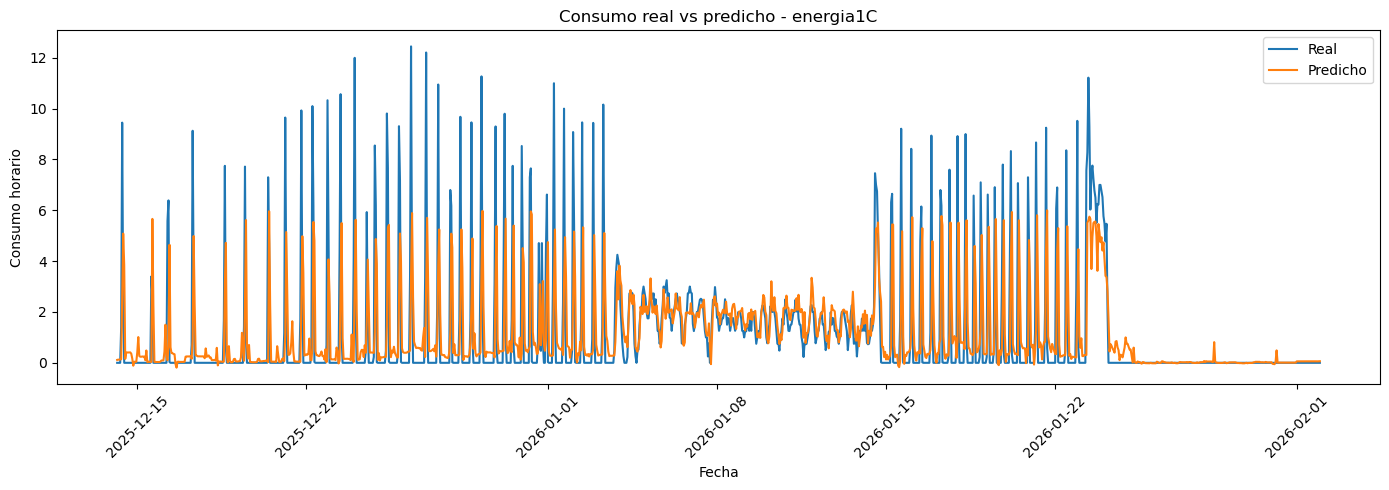

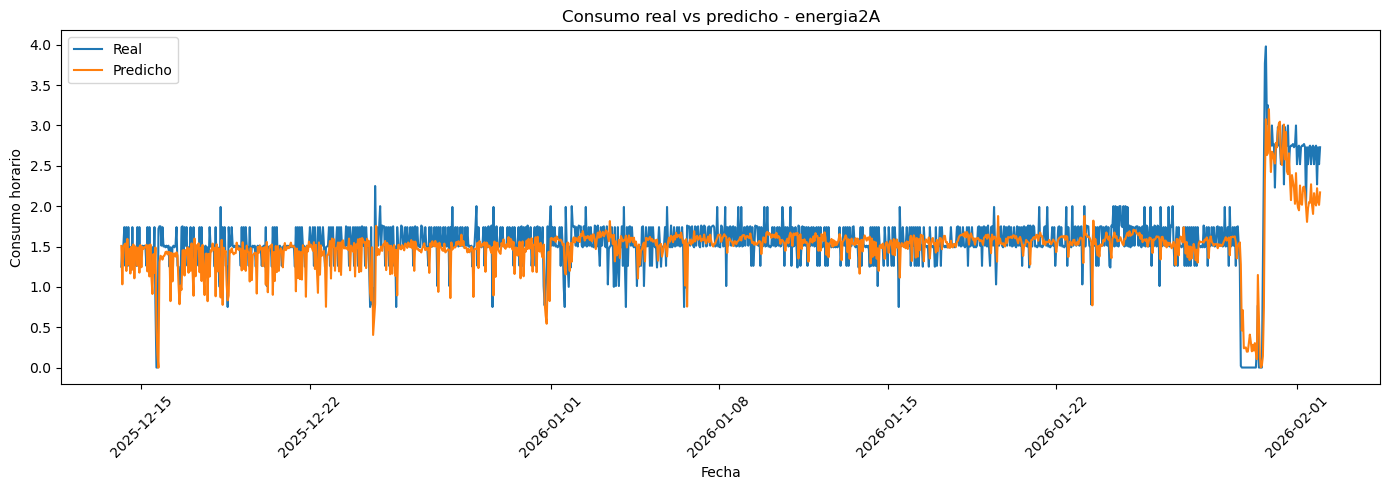

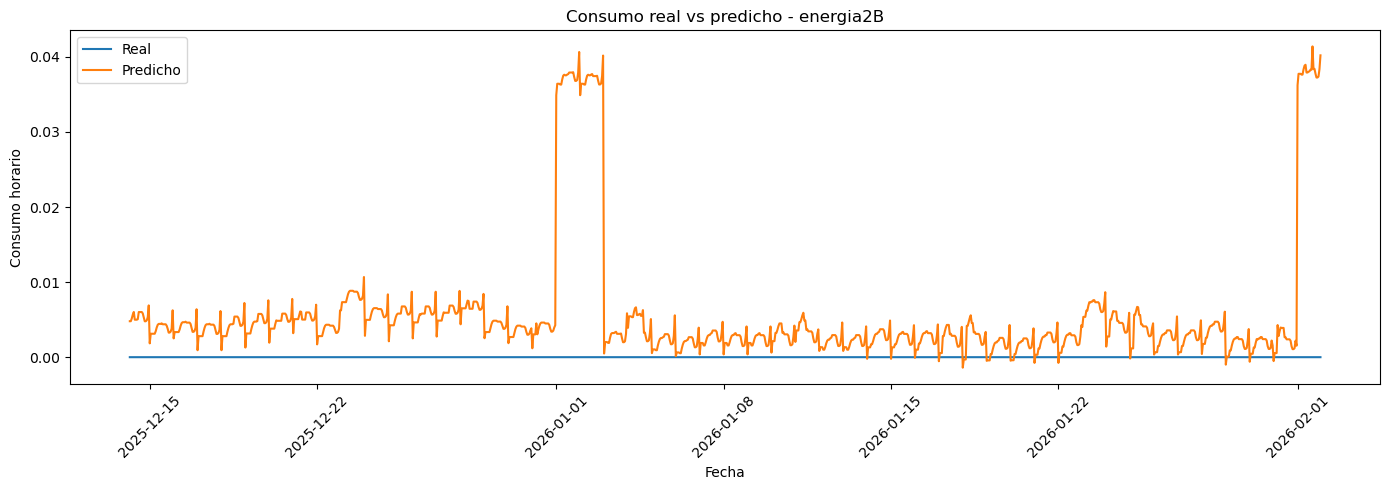

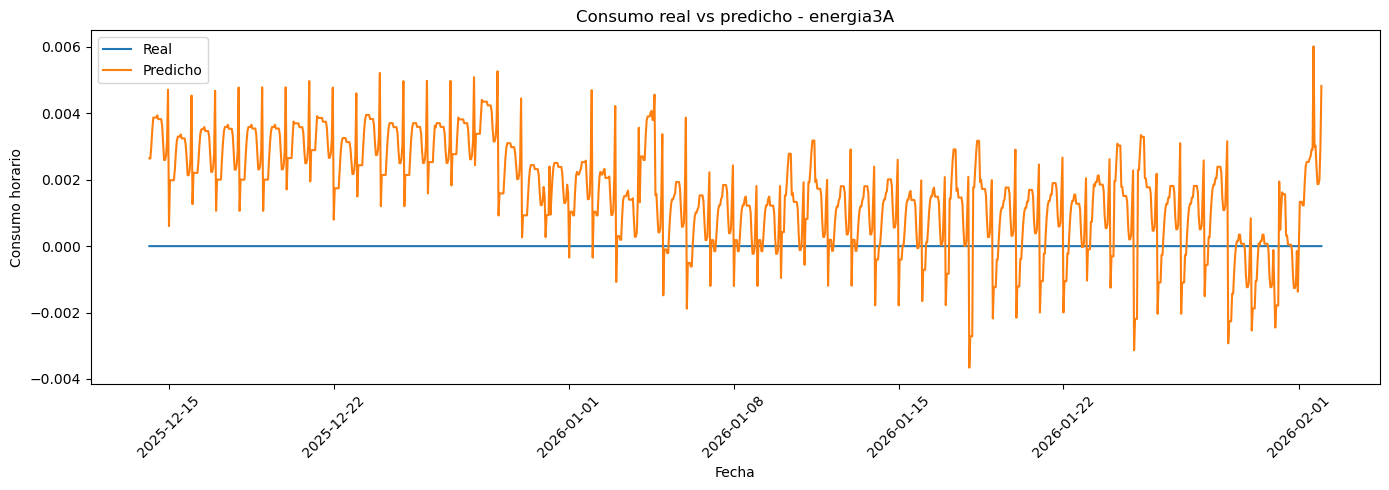

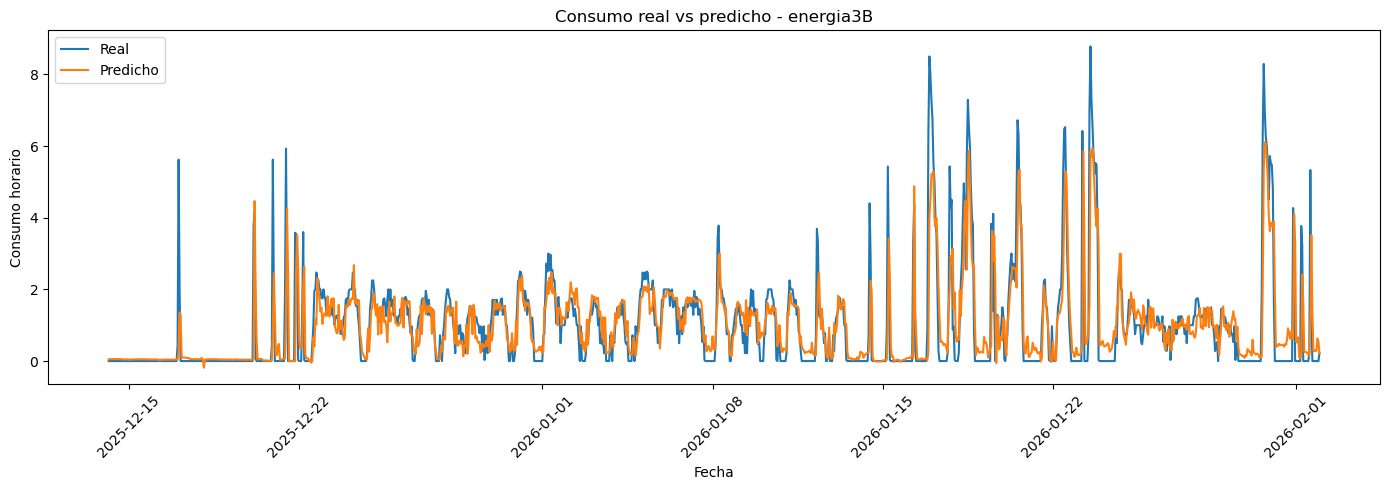

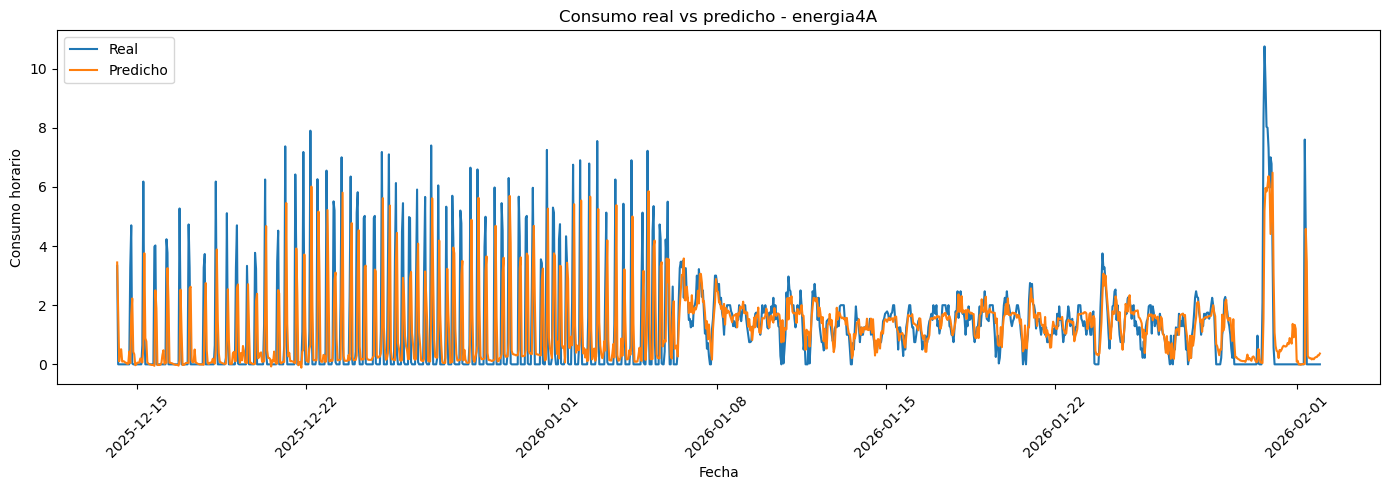

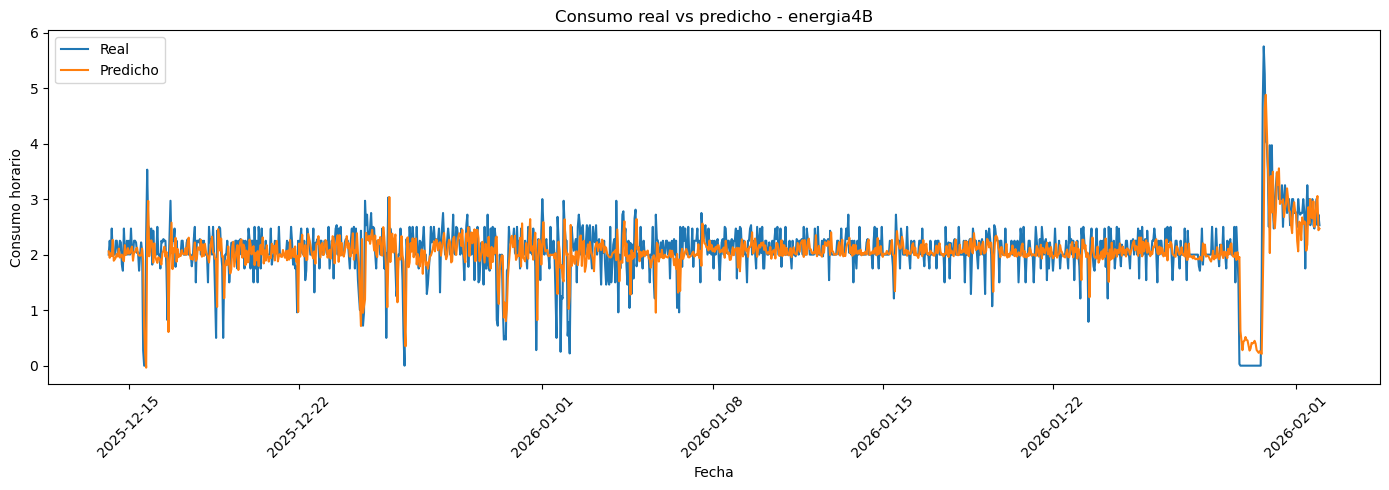

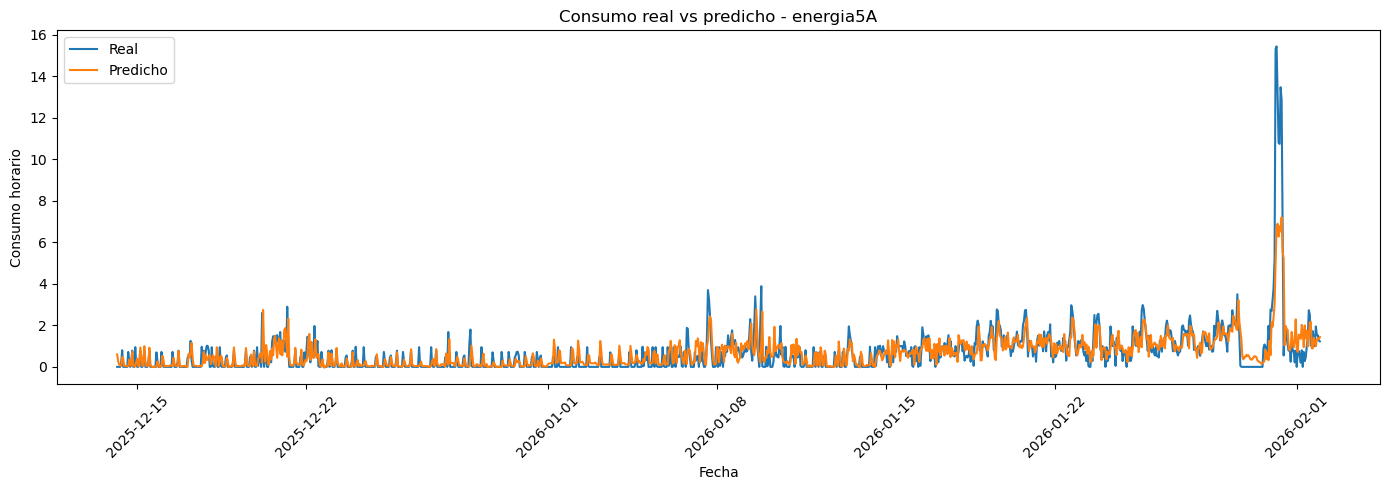

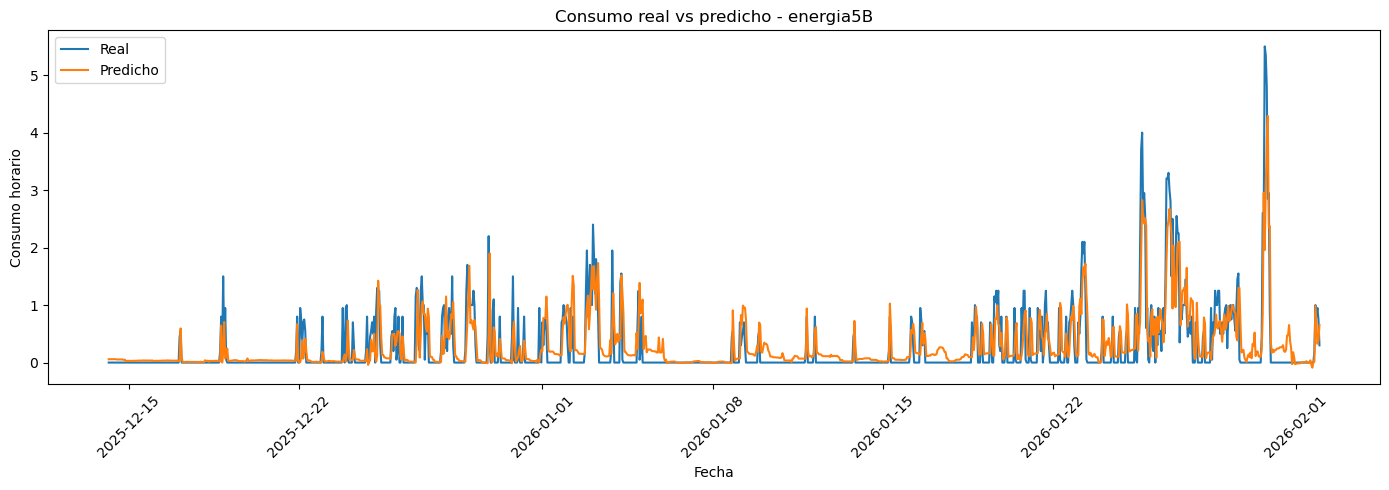

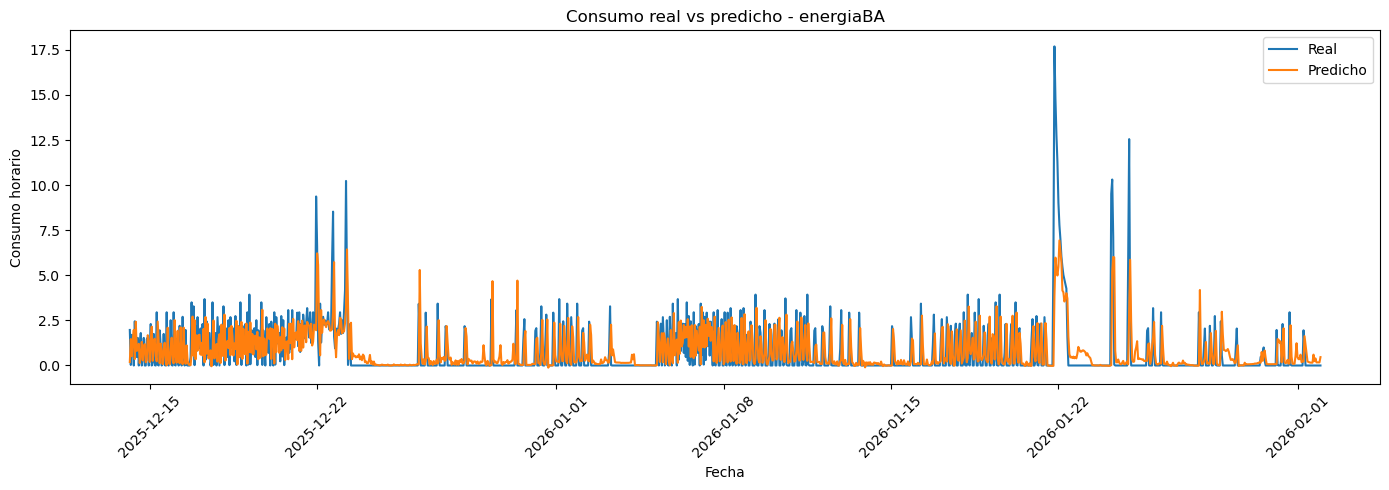

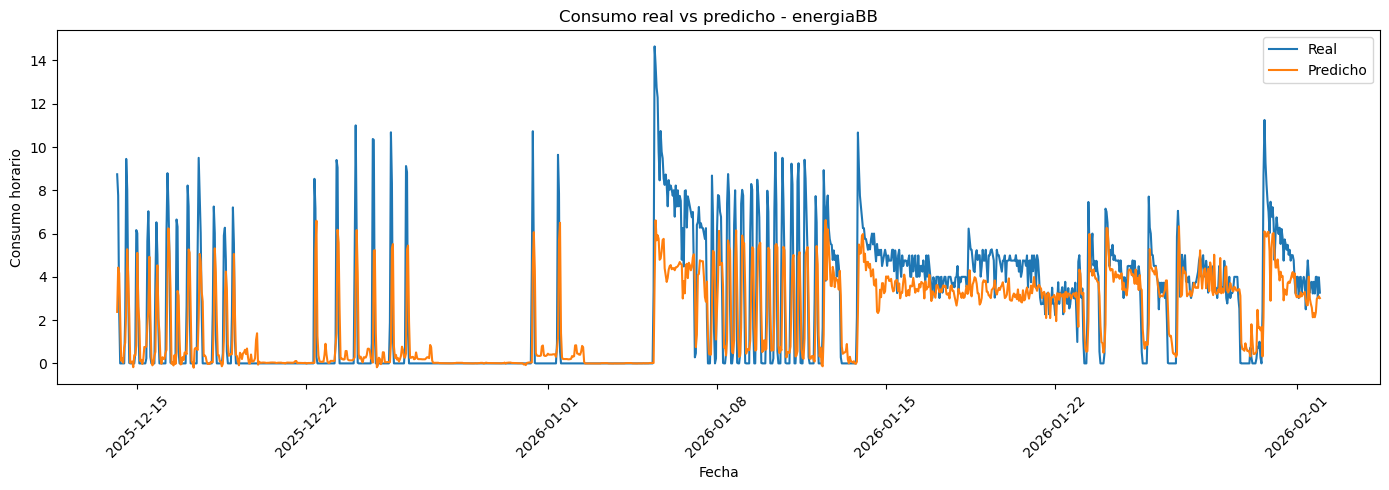

In [ ]:
for vivienda in results["vivienda"].unique():
    r = results[results["vivienda"] == vivienda].copy()

    plt.figure(figsize=(14,5))
    plt.plot(r["fecha"], r["consumo"], label="Real")
    plt.plot(r["fecha"], r["pred"], label="Predicho")
    plt.title(f"Consumo real vs predicho - {vivienda}")
    plt.xlabel("Fecha")
    plt.ylabel("Consumo horario")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()